# TITANIC SURVIVAL PREDICTION
This workbook demonstrates usage of ML models to predict survival of passengers onboard the Titanic.

In [1381]:
import opendatasets as od
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif,RFECV,mutual_info_regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.compose import make_column_selector,make_column_transformer,ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
import tensorflow as tf
from scipy import stats
from sklearn.impute import KNNImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report,roc_auc_score,roc_curve
from category_encoders import MEstimateEncoder
from sklearn.decomposition import PCA
from lightgbm import LGBMClassifier
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
import xgboost as xgb
from sklearn.utils import shuffle
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import re
from scipy.stats import randint,uniform
from sklearn.model_selection import learning_curve,LearningCurveDisplay

In [1262]:
od.download_kaggle_dataset("https://www.kaggle.com/competitions/titanic",data_dir="./datasets")

Skipping, found downloaded files in "./datasets/titanic" (use force=True to force download)


In [1263]:
titanic_train_df = pd.read_csv("./datasets/titanic/train.csv")
titanic_test_df = pd.read_csv("./datasets/titanic/test.csv")

In [1264]:
titanic_train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [1265]:
X_train = titanic_train_df.copy()
X_test = titanic_test_df.copy()

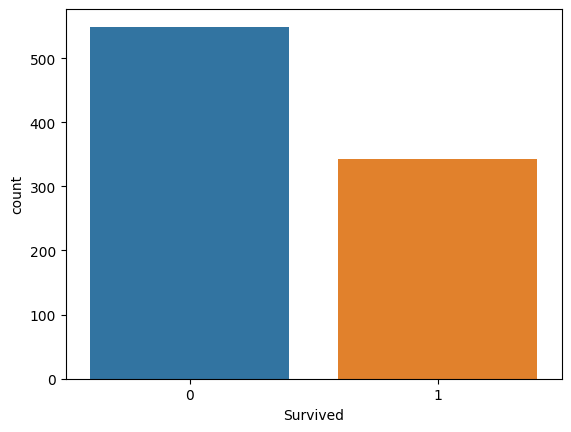

In [1266]:
y_train = X_train.pop('Survived')
sns.countplot(x=y_train)
plt.show()

In [1267]:
X_train.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [1268]:
X_test.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [1269]:
X_train.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Observations,
1. There were 891 passengers aboard the titanic when it sank. 

2. Passengers were divided into 3 classes. 1st = Upper, 2nd = Middle, 3rd = Lower. 

3. Average age of passengers were just under 30 yrs with minimum being just half a year (i.e. a newborn) and max 80 yrs. 

4. Of all the passengers max siblings/spouses aboard the Titanic was 8. 

5. Max parents/children aboard for any passenger was 6. 

6. Avg ticket price was just over 30$ with the maximum being 512$. 


VISUALISE DIFFERENT FEATURES

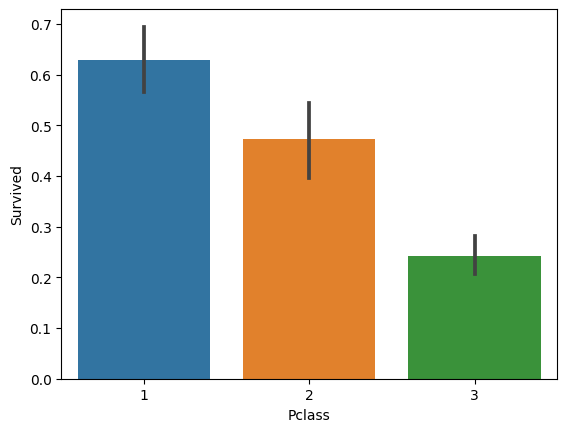

In [1270]:
# let's look at whether ticket class and survival are related.
sns.barplot(x=X_train["Pclass"],y=y_train)
plt.show()

Observations,
1. Most passengers belonged to 3rd class followed by 1st and 2nd classes. 

2. Of all the passengers most of them who belonged to 1st class survived.

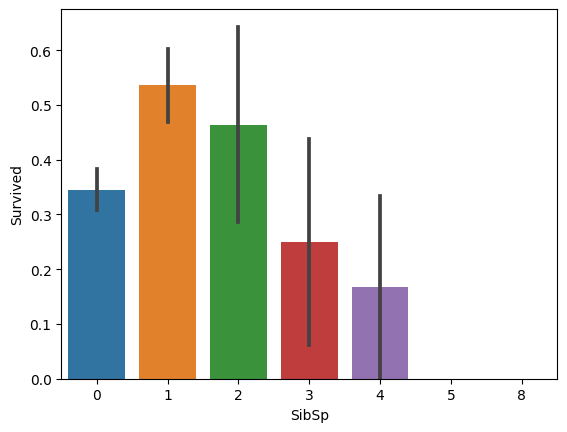

In [1271]:
sns.barplot(x=X_train['SibSp'],y=y_train)
plt.show()

Observations, 
1. Survival rate in general reduces with more siblings/spouses present. 
2. Passengers with no siblings/spouses show reduced survival rates.

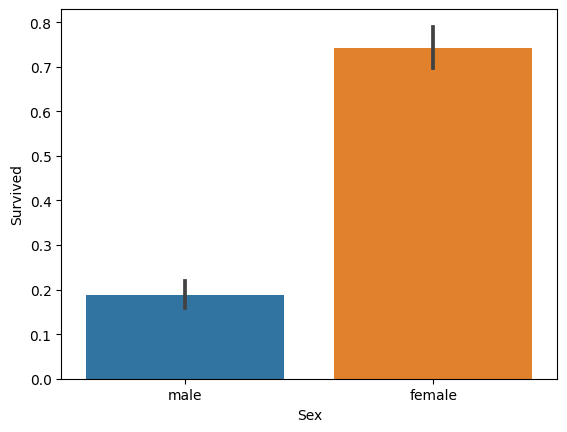

In [1272]:
sns.barplot(x=X_train['Sex'],y=y_train)
plt.show()

Observations, 
1. Female passengers survived the most.

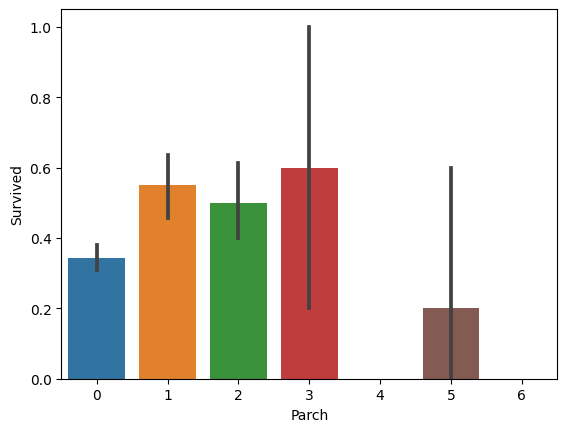

In [1273]:
sns.barplot(x=X_train['Parch'],y=y_train)
plt.show()

Observations, 
1. Passengers with the largest parents/children has the highest survival rate. 
2. Passengers who travelled solo show the lowest rate of survival. Survival rate increases with rise in parents or children from 0-1, reduces from 1-2 & then increases sharply from 2-3.

In [1274]:
X_train = X_train.join(y_train)

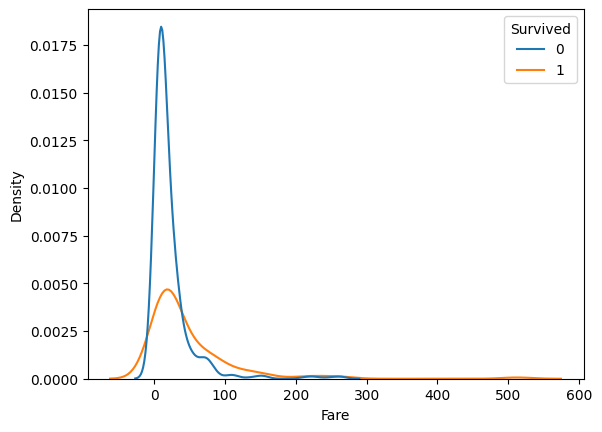

In [1275]:
sns.kdeplot(data=X_train,x="Fare",hue="Survived")
plt.show()

Observations, 
1. Above plot is highly right skewed which indicates presence of outliers thereby extendending the right tail hence we perform log-transform to compress the right tail so we can handle the outliers better. This is more important in regression tasks where the loss function depends on residual. 
 
2. Passengers who paid more has higher survival rate.

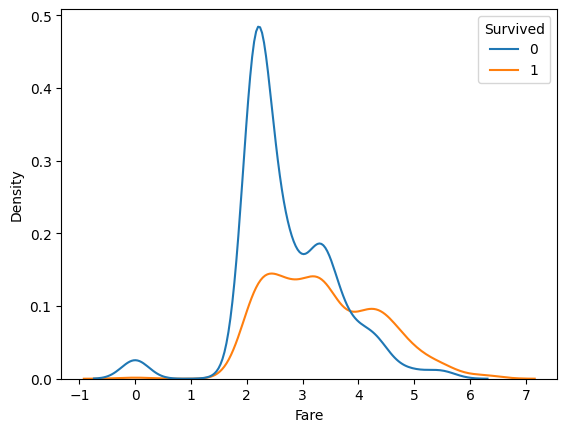

In [1276]:
X_train['Fare'] = np.log1p(X_train['Fare'])
sns.kdeplot(data=X_train,x="Fare",hue="Survived")
plt.show()

Impute missing **Fare** value in test set and transform. 

since **Fare** is related to class we impute the missing value as the mean value of that class in train set.

In [1277]:
X_test[X_test['Fare'].isna()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [1278]:
X_test['Fare']=X_test['Fare'].fillna(X_train[X_train['Pclass']==3]['Fare'].mean())

In [1279]:
X_test['Fare'].isna().any()

False

In [1280]:
X_test['Fare'] = np.log1p(X_test['Fare'])

Observations, 
1. As opposed to the previous plot this one looks roughly gaussian with the right tail compressed.

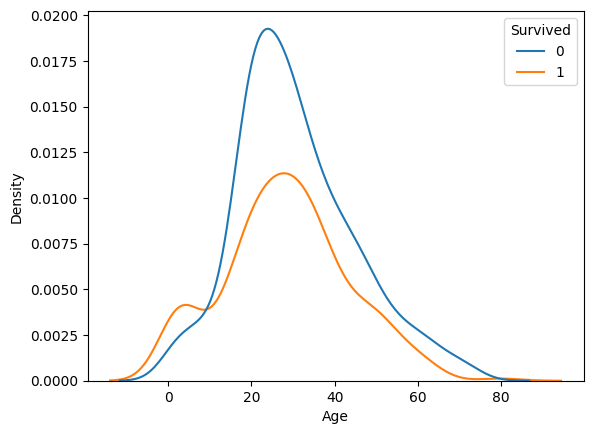

In [1281]:
sns.kdeplot(data=X_train,x="Age",hue="Survived")
plt.show()

Observations, 
1. From the plot above it looks that children & olders have better survival chances. To better visualise we bin age into groups.

In [1282]:
X_train[X_train['Age'].isna()][:5]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
5,6,3,"Moran, Mr. James",male,NaN,0,0,330877,2.246893,NaN,Q,0
17,18,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,2.639057,NaN,S,1
19,20,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,2.107178,NaN,C,1
26,27,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,2.107178,NaN,C,0
28,29,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,2.183711,NaN,Q,1


EXTRACTING TICKET AND CABIN ATTRIBUTES

Here for tickets we split it at ' ' to have 2 parts for some such as **STON/O 2. 3101293** while 1 for others such as **113043** and keep the 2nd part. 

For cabin which largely contains 0s and the ones with values such as **C124** or **B58 B60**  or **F E69** we extract the first alphabet which might suggest cabin sequence on the ship.

In [1283]:
X_train.isna().sum(),X_test.isna().sum()

(PassengerId      0
 Pclass           0
 Name             0
 Sex              0
 Age            177
 SibSp            0
 Parch            0
 Ticket           0
 Fare             0
 Cabin          687
 Embarked         2
 Survived         0
 dtype: int64,
 PassengerId      0
 Pclass           0
 Name             0
 Sex              0
 Age             86
 SibSp            0
 Parch            0
 Ticket           0
 Fare             0
 Cabin          327
 Embarked         0
 dtype: int64)

In [1284]:
X_train['Family_size'] = X_train['Parch'] + X_train['SibSp']
X_test['Family_size'] = X_test['Parch'] + X_test['SibSp']

In [1285]:
X_train.drop(columns=['SibSp','Parch'],inplace=True)
X_test.drop(columns=['SibSp','Parch'],inplace=True)

#### IMPUTING TICKET AND CABIN BASIS FARE
We impute missing **Cabin** basis **mean Fare** values while removing **Ticket** column. 

When imputing missing **Cabin** we only consider the first letter.

In [1286]:
X_train.head()

,PassengerId,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked,Survived,Family_size
0,1,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,2.110213,NaN,S,0,1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,4.280593,C85,C,1,1
2,3,3,"Heikkinen, Miss. Laina",female,26.0,STON/O2. 3101282,2.188856,NaN,S,1,0
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,113803,3.990834,C123,S,1,1
4,5,3,"Allen, Mr. William Henry",male,35.0,373450,2.202765,NaN,S,0,0


In [1287]:
# drop tickets
X_train.drop(columns=['Ticket'],inplace=True)
X_test.drop(columns=['Ticket'],inplace=True)

In [1288]:
X_train['Cabin'] = X_train['Cabin'].str[0]

In [1289]:
X_train['Cabin'].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [1290]:
# extract cabin sequence
X_train.groupby(['Cabin'])['Fare'].mean().sort_values()

Cabin
G    2.656323
F    2.813977
A    3.477373
T    3.597312
E    3.605621
D    3.900584
B    4.278497
C    4.375715
Name: Fare, dtype: float64

In [1291]:
def cabin_estimator(cabin_fare):
    '''
    Function to assign cabin to missing ones basis mean fare.
    '''

    if cabin_fare<=2.6563:
        return 'G'
    elif cabin_fare<=2.8139:
        return 'F'
    elif cabin_fare<=3.4773:
        return 'A'
    elif cabin_fare<=3.5973:
        return 'T'
    elif cabin_fare<=3.6056:
        return 'E'
    elif cabin_fare<=3.9005:
        return 'D'
    elif cabin_fare<=4.2784:
        return 'B'
    else:
        return 'C'

In [1292]:
X_train_null_cabins = X_train[X_train['Cabin'].isna()]
null_cabins_imputed = [cabin_estimator(cabin_fare) for cabin_fare in X_train_null_cabins['Fare']]

# replace missing cabins
X_train.loc[X_train_null_cabins.index,'Cabin'] = null_cabins_imputed

In [1293]:
X_train['Cabin'].isna().sum()

0

In [1294]:
X_test['Cabin'] = X_test['Cabin'].str[0]
X_test.groupby(['Cabin'])['Fare'].mean()

Cabin
A    3.711020
B    4.472995
C    4.584890
D    3.638897
E    4.335445
F    2.683895
G    2.873565
Name: Fare, dtype: float64

In [1295]:
X_test.groupby(['Cabin'])['Fare'].mean().sort_values()

Cabin
F    2.683895
G    2.873565
D    3.638897
A    3.711020
E    4.335445
B    4.472995
C    4.584890
Name: Fare, dtype: float64

In [1296]:
X_test_null_cabins = X_test[X_test['Cabin'].isna()]
null_cabins_test_imputed = [cabin_estimator(cabin_fare) for cabin_fare in X_test_null_cabins['Fare']]

# replace missing cabins
X_test.loc[X_test_null_cabins.index,'Cabin'] = null_cabins_test_imputed

In [1297]:
X_test['Cabin'].isna().sum()

0

In [1298]:
X_train.head()

,PassengerId,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,Survived,Family_size
0,1,3,"Braund, Mr. Owen Harris",male,22.0,2.110213,G,S,0,1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,4.280593,C,C,1,1
2,3,3,"Heikkinen, Miss. Laina",female,26.0,2.188856,G,S,1,0
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,3.990834,C,S,1,1
4,5,3,"Allen, Mr. William Henry",male,35.0,2.202765,G,S,0,0


VISUALISE IMPACT OF CABIN SURVIVAL

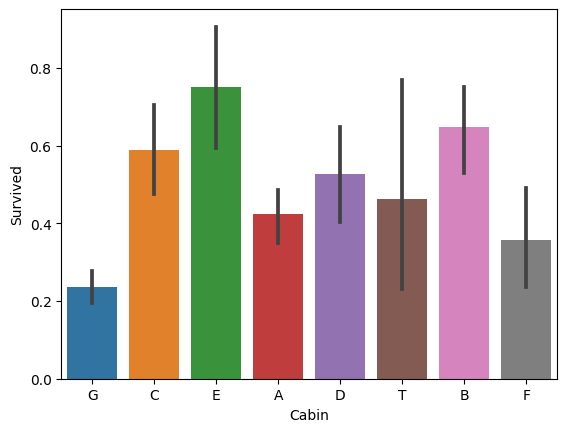

In [1299]:
sns.barplot(x=X_train['Cabin'],y=X_train['Survived'])
plt.show()

EXTRACTING NAME TITLES

For "Name" attribute we extract titles to check whether being someone established helped survive the disaster.

In [1300]:
X_train['Name'].unique()[:5]

array(['Braund, Mr. Owen Harris',
       'Cumings, Mrs. John Bradley (Florence Briggs Thayer)',
       'Heikkinen, Miss. Laina',
       'Futrelle, Mrs. Jacques Heath (Lily May Peel)',
       'Allen, Mr. William Henry'], dtype=object)

In [1301]:
X_train['titles'] = X_train['Name'].apply(lambda row:row.split('.')[0].split(' ')[-1] if not(row==np.nan) else 0)
X_train['titles'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess',
       'Jonkheer'], dtype=object)

In [1302]:
X_test['titles'] = X_test['Name'].apply(lambda row:row.split('.')[0].split(' ')[-1] if not(row==np.nan) else 0)
X_test['titles'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Ms', 'Col', 'Rev', 'Dr', 'Dona'],
      dtype=object)

We keep the following titles
- Capt,Col,Countess,Dr

In [1303]:
def Name_converted(title):
    '''
    Function that helps modify title column
    '''

    name = ''

    if title in ['Countess','Capt','Lady','Sir','Jonkheer','Don','Major','Col', 'Rev', 'Dona', 'Dr']:
        name = 'Rare'
    elif title in ['Ms', 'Mlle']:
        name = 'Miss'
    elif title in ['Mme']:
        name = 'Mrs'
    else:
        name = title
    
    return name

In [1304]:
X_train['new_title'] = X_train['titles'].apply(lambda x:Name_converted(x))
X_test['new_title'] = X_test['titles'].apply(lambda x:Name_converted(x))

In [1305]:
X_train.head()

,PassengerId,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,Survived,Family_size,titles,new_title
0,1,3,"Braund, Mr. Owen Harris",male,22.0,2.110213,G,S,0,1,Mr,Mr
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,4.280593,C,C,1,1,Mrs,Mrs
2,3,3,"Heikkinen, Miss. Laina",female,26.0,2.188856,G,S,1,0,Miss,Miss
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,3.990834,C,S,1,1,Mrs,Mrs
4,5,3,"Allen, Mr. William Henry",male,35.0,2.202765,G,S,0,0,Mr,Mr


In [1306]:
X_train.drop(columns=['titles'],inplace=True)
X_test.drop(columns=['titles'],inplace=True)

X_train.rename(columns={'new_title':'title'},inplace=True)
X_test.rename(columns={'new_title':'title'},inplace=True)

In [1307]:
X_train.head()

,PassengerId,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,Survived,Family_size,title
0,1,3,"Braund, Mr. Owen Harris",male,22.0,2.110213,G,S,0,1,Mr
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,4.280593,C,C,1,1,Mrs
2,3,3,"Heikkinen, Miss. Laina",female,26.0,2.188856,G,S,1,0,Miss
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,3.990834,C,S,1,1,Mrs
4,5,3,"Allen, Mr. William Henry",male,35.0,2.202765,G,S,0,0,Mr


VISUALISING IMPACT OF TITLES ON SURVIVAL RATE

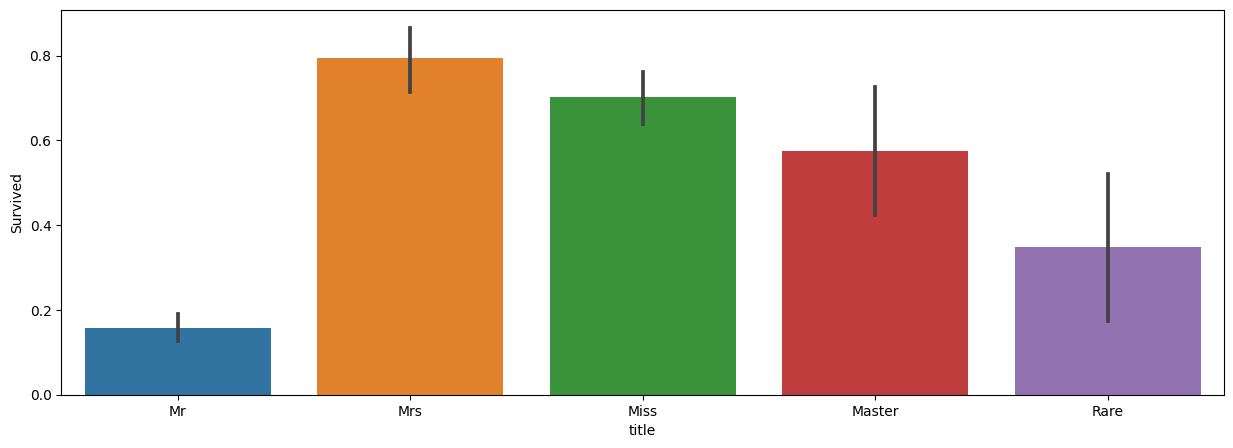

In [1308]:
plt.figure(figsize=(15,5))
sns.barplot(x=X_train['title'],y=X_train['Survived'])
plt.show()

Observations, 
1. The plot above indicates that passengers who are female and belonged to higher class indicative of the titles "Lady","Countess" etc. has higher survival rates. 
2. In general titles associated to female shows higher rates of survival as opposed to male.

### PROCESSING

In [1309]:
# perform nested cv leakage-safe target encoding
def Target_Encoding(X_tr,X_test,target_col,cols_to_be_target_enc,n_splits,seed):
    '''
    Perform OOF leakage-safe target encoding to create new features.
    '''
    # dataframes to store encoded columns
    te_train = pd.DataFrame(index=X_tr.index)
    te_test = pd.DataFrame(index=X_test.index)

    y = X_tr[target_col]

    skf = StratifiedKFold(n_splits=n_splits,shuffle=True,random_state=seed)

    for col in cols_to_be_target_enc:
        oof = np.zeros(len(X_tr),dtype=float)

        for tr_idx,va_idx in skf.split(X_tr,y):
            tr_fold = X_tr.iloc[tr_idx]
            va_fold = X_tr.iloc[va_idx]

            mean_map = tr_fold.groupby(col)[target_col].mean()
            oof[va_idx] = va_fold[col].map(mean_map).astype(float).fillna(0)

        te_train[f'te_{col}'] = oof

        #Global map for test
        global_map = X_tr.groupby(col)[target_col].mean()
        te_test[f'te_{col}'] = X_test[col].map(global_map).astype(float).fillna(0)
    
    return te_train,te_test

In [1310]:
X_train.head()

,PassengerId,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,Survived,Family_size,title
0,1,3,"Braund, Mr. Owen Harris",male,22.0,2.110213,G,S,0,1,Mr
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,4.280593,C,C,1,1,Mrs
2,3,3,"Heikkinen, Miss. Laina",female,26.0,2.188856,G,S,1,0,Miss
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,3.990834,C,S,1,1,Mrs
4,5,3,"Allen, Mr. William Henry",male,35.0,2.202765,G,S,0,0,Mr


In [1311]:
X_train.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age            177
Fare             0
Cabin            0
Embarked         2
Survived         0
Family_size      0
title            0
dtype: int64

In [1312]:
X_train[X_train['Embarked'].isna()]

,PassengerId,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,Survived,Family_size,title
61,62,1,"Icard, Miss. Amelie",female,38.0,4.394449,B,NaN,1,0,Miss
829,830,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,4.394449,B,NaN,1,0,Mrs


We impute missing **Embarked** basis which port of embankement has highest survival chances.

In [1313]:
X_train.groupby(['Embarked'])['Survived'].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

In [1314]:
X_train['Embarked']=X_train['Embarked'].fillna('C')
X_train['Embarked'].isna().any()

False

In [1315]:
print(f'Missing Age entries in the database is : {np.sum(np.isnan(np.array(X_train.Age)))/len(X_train)}')

Missing Age entries in the database is : 0.19865319865319866


Since **Age** is a crucial attribute towards predicting target and around 20% value is missing we use a **Random Forest Regressor** to impute the missing values.

In [1316]:
X_train.head()

,PassengerId,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,Survived,Family_size,title
0,1,3,"Braund, Mr. Owen Harris",male,22.0,2.110213,G,S,0,1,Mr
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,4.280593,C,C,1,1,Mrs
2,3,3,"Heikkinen, Miss. Laina",female,26.0,2.188856,G,S,1,0,Miss
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,3.990834,C,S,1,1,Mrs
4,5,3,"Allen, Mr. William Henry",male,35.0,2.202765,G,S,0,0,Mr


In [1317]:
# let us drop PassengerID,Name,Ticket,Cabin attribute from both train & test sets
X_train.drop(columns=['PassengerId','Name'],inplace=True)
X_test.drop(columns=['PassengerId','Name'],inplace=True)

In [1318]:
X_train.head()

,Pclass,Sex,Age,Fare,Cabin,Embarked,Survived,Family_size,title
0,3,male,22.0,2.110213,G,S,0,1,Mr
1,1,female,38.0,4.280593,C,C,1,1,Mrs
2,3,female,26.0,2.188856,G,S,1,0,Miss
3,1,female,35.0,3.990834,C,S,1,1,Mrs
4,3,male,35.0,2.202765,G,S,0,0,Mr


In [1319]:
X_train.isna().sum()

Pclass           0
Sex              0
Age            177
Fare             0
Cabin            0
Embarked         0
Survived         0
Family_size      0
title            0
dtype: int64

In [1320]:
X_test.isna().sum()

Pclass          0
Sex             0
Age            86
Fare            0
Cabin           0
Embarked        0
Family_size     0
title           0
dtype: int64

In [1321]:
y_train = X_train.pop('Survived')

In [1322]:
X_train[['Sex','Cabin','Embarked','title']].nunique()

Sex         2
Cabin       8
Embarked    3
title       5
dtype: int64

#### TARGET ENCODE 
We perform Target Encoding of the following categorical columns 
1. Sex 
2. Embarked 
3. Cabin_seq 
4. Titles 

Once performed we omit the above features from both train & test sets.

In [1323]:
cat_cols = list(X_train.select_dtypes(include=object))
X_train = X_train.join(y_train)

te_train,te_test = Target_Encoding(X_train,X_test,'Survived',cat_cols,5,42)

In [1324]:
X_train = X_train.join(te_train)
X_test = X_test.join(te_test)

In [1325]:
X_train.head()

,Pclass,Sex,Age,Fare,Cabin,Embarked,Family_size,title,Survived,te_Sex,te_Cabin,te_Embarked,te_title
0,3,male,22.0,2.110213,G,S,1,Mr,0,0.183807,0.236025,0.339731,0.156098
1,1,female,38.0,4.280593,C,C,1,Mrs,1,0.734694,0.580645,0.570423,0.776596
2,3,female,26.0,2.188856,G,S,0,Miss,1,0.756098,0.232628,0.337891,0.719424
3,1,female,35.0,3.990834,C,S,1,Mrs,1,0.756098,0.582090,0.337891,0.798077
4,3,male,35.0,2.202765,G,S,0,Mr,0,0.190065,0.248485,0.336557,0.159524


In [1326]:
# omit original features from both train & test sets
X_train.drop(columns=cat_cols,inplace=True)
X_test.drop(columns=cat_cols,inplace=True)

In [1327]:
X_train.head()

,Pclass,Age,Fare,Family_size,Survived,te_Sex,te_Cabin,te_Embarked,te_title
0,3,22.0,2.110213,1,0,0.183807,0.236025,0.339731,0.156098
1,1,38.0,4.280593,1,1,0.734694,0.580645,0.570423,0.776596
2,3,26.0,2.188856,0,1,0.756098,0.232628,0.337891,0.719424
3,1,35.0,3.990834,1,1,0.756098,0.582090,0.337891,0.798077
4,3,35.0,2.202765,0,0,0.190065,0.248485,0.336557,0.159524


In [1328]:
y_train = X_train.pop('Survived')

#### IMPUTING AGE WITH RANDOM FOREST REGRESSOR

Since **Age** shows non-linear relationship with the target variable with >=5% data missing we use a Random Forest Regressor to impute missing **Age** values to come up with values that closely resembles true distribution.

In [1329]:
X_train.head()

,Pclass,Age,Fare,Family_size,te_Sex,te_Cabin,te_Embarked,te_title
0,3,22.0,2.110213,1,0.183807,0.236025,0.339731,0.156098
1,1,38.0,4.280593,1,0.734694,0.580645,0.570423,0.776596
2,3,26.0,2.188856,0,0.756098,0.232628,0.337891,0.719424
3,1,35.0,3.990834,1,0.756098,0.582090,0.337891,0.798077
4,3,35.0,2.202765,0,0.190065,0.248485,0.336557,0.159524


In [1330]:
# arrange columns such that Age comes first followed by others both in train & test
X_train = X_train[['Age','Pclass','Fare','Family_size','te_Sex','te_Embarked','te_Cabin','te_title']]
X_test = X_test[['Age','Pclass','Fare','Family_size','te_Sex','te_Embarked','te_Cabin','te_title']]

In [1331]:
X_train.head()

,Age,Pclass,Fare,Family_size,te_Sex,te_Embarked,te_Cabin,te_title
0,22.0,3,2.110213,1,0.183807,0.339731,0.236025,0.156098
1,38.0,1,4.280593,1,0.734694,0.570423,0.580645,0.776596
2,26.0,3,2.188856,0,0.756098,0.337891,0.232628,0.719424
3,35.0,1,3.990834,1,0.756098,0.337891,0.582090,0.798077
4,35.0,3,2.202765,0,0.190065,0.336557,0.248485,0.159524


In [1332]:
X_train.isna().sum()

Age            177
Pclass           0
Fare             0
Family_size      0
te_Sex           0
te_Embarked      0
te_Cabin         0
te_title         0
dtype: int64

In [1333]:
X_test.isna().sum()

Age            86
Pclass          0
Fare            0
Family_size     0
te_Sex          0
te_Embarked     0
te_Cabin        0
te_title        0
dtype: int64

In [1334]:
# extract test set as those entries with NA Age values.
X_age_test = X_train[X_train['Age'].isna()]
X_age_test.drop(columns=['Age'],inplace=True)

X_age_train = X_train.drop(X_age_test.index)
y = X_age_train.pop('Age')

# define model instance
rf_regreesor = RandomForestRegressor(random_state=42,n_estimators=1000)

# fit model on train set
rf_regreesor.fit(X_age_train,y)

# predict missing age values on test set
age_pred = rf_regreesor.predict(X_age_test)

/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_54651/1007022625.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_age_test.drop(columns=['Age'],inplace=True)


In [1335]:
# replace missing Age with the predicted age
X_train.loc[X_age_test.index,'Age'] = age_pred

In [1336]:
X_test_age_missing = X_test[X_test['Age'].isna()]
X_test_age_missing.drop(columns=['Age'],inplace=True)

# predict missing ages on test set
age_pred_test = rf_regreesor.predict(X_test_age_missing)

#replace missing ages
X_test.loc[X_test_age_missing.index,'Age'] = age_pred_test

/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_54651/1419884068.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_age_missing.drop(columns=['Age'],inplace=True)


In [1337]:
X_test.isna().sum()

Age            0
Pclass         0
Fare           0
Family_size    0
te_Sex         0
te_Embarked    0
te_Cabin       0
te_title       0
dtype: int64

In [1338]:
X_train.isna().sum()

Age            0
Pclass         0
Fare           0
Family_size    0
te_Sex         0
te_Embarked    0
te_Cabin       0
te_title       0
dtype: int64

In [1339]:
X_test.head()

,Age,Pclass,Fare,Family_size,te_Sex,te_Embarked,te_Cabin,te_title
0,34.5,3,2.178064,0,0.188908,0.389610,0.237164,0.156673
1,47.0,3,2.079442,1,0.742038,0.336957,0.237164,0.793651
2,62.0,2,2.369075,0,0.188908,0.389610,0.237164,0.156673
3,27.0,3,2.268252,0,0.188908,0.336957,0.237164,0.156673
4,22.0,3,2.586824,2,0.742038,0.336957,0.237164,0.793651


In [1340]:
X_train.head()

,Age,Pclass,Fare,Family_size,te_Sex,te_Embarked,te_Cabin,te_title
0,22.0,3,2.110213,1,0.183807,0.339731,0.236025,0.156098
1,38.0,1,4.280593,1,0.734694,0.570423,0.580645,0.776596
2,26.0,3,2.188856,0,0.756098,0.337891,0.232628,0.719424
3,35.0,1,3.990834,1,0.756098,0.337891,0.582090,0.798077
4,35.0,3,2.202765,0,0.190065,0.336557,0.248485,0.159524


#### BINNING CONTINUOUS NUMERICAL VARIABLES
Here we bin continuous numerical attributes such as Age & Fare into 5 groups each such that, 
1. Age => 'child','teens','adult','aged' 
2. Fare => 'low','medium', 'high' 

In [1341]:
def Safe_Binning(age,bins):
    '''
    Function that discretizes numerical feature in test set taking care of values that fall outside bin edges.
    Parameters : 
    Age - must be valid
    Bins - Array of bin edges
    '''
    if age<bins[0]:
        return 0
    
    if age>bins[-1]:
        return len(bins)-2

    return pd.cut([age],bins=bins,labels=False,include_lowest=True).astype(float)[0]
    

In [1342]:
X_train.columns

Index(['Age', 'Pclass', 'Fare', 'Family_size', 'te_Sex', 'te_Embarked',
       'te_Cabin', 'te_title'],
      dtype='object')

In [1343]:
X_train = X_train.join(y_train)

In [1344]:
train_age_bins,age_bins = pd.qcut(X_train['Age'],q=4,retbins=True,labels=False,duplicates='drop')

In [1345]:
X_train['Age_binned'] = train_age_bins

# safe binning of Age column in test set
X_test['Age_binned'] = X_test['Age'].apply(lambda row: Safe_Binning(row,age_bins))

In [1346]:
# discretise Fare column
train_fare_bins,fare_bins = pd.qcut(X_train['Fare'],q=3,retbins=True,labels=False,duplicates='drop')

X_train['Fare_binned'] = train_fare_bins

# Safe binning of Fare column in test set
X_test['Fare_binned'] = X_test['Fare'].apply(lambda row: Safe_Binning(row,fare_bins))

In [1347]:
X_test.isna().sum()

Age            0
Pclass         0
Fare           0
Family_size    0
te_Sex         0
te_Embarked    0
te_Cabin       0
te_title       0
Age_binned     0
Fare_binned    0
dtype: int64

In [1348]:
X_test.head()

,Age,Pclass,Fare,Family_size,te_Sex,te_Embarked,te_Cabin,te_title,Age_binned,Fare_binned
0,34.5,3,2.178064,0,0.188908,0.389610,0.237164,0.156673,2.0,0.0
1,47.0,3,2.079442,1,0.742038,0.336957,0.237164,0.793651,3.0,0.0
2,62.0,2,2.369075,0,0.188908,0.389610,0.237164,0.156673,3.0,1.0
3,27.0,3,2.268252,0,0.188908,0.336957,0.237164,0.156673,1.0,0.0
4,22.0,3,2.586824,2,0.742038,0.336957,0.237164,0.793651,1.0,1.0


In [1349]:
X_test = X_test[['Age', 'Pclass', 'Fare', 'Family_size', 'te_Sex',
       'te_Embarked', 'te_Cabin', 'te_title','Age_binned','Fare_binned']]

In [1350]:
X_test.head()

,Age,Pclass,Fare,Family_size,te_Sex,te_Embarked,te_Cabin,te_title,Age_binned,Fare_binned
0,34.5,3,2.178064,0,0.188908,0.389610,0.237164,0.156673,2.0,0.0
1,47.0,3,2.079442,1,0.742038,0.336957,0.237164,0.793651,3.0,0.0
2,62.0,2,2.369075,0,0.188908,0.389610,0.237164,0.156673,3.0,1.0
3,27.0,3,2.268252,0,0.188908,0.336957,0.237164,0.156673,1.0,0.0
4,22.0,3,2.586824,2,0.742038,0.336957,0.237164,0.793651,1.0,1.0


### MUTUAL INFORMATION, PEARSON CORRELATION AND CHI-SQUARE TESTS

We perform statistical tests such as **MI(Mutual Information)** & **CHI-SQUARE TESTS** for numerical and categorical attributes to check their association to the target.

In [1351]:
# compute mutual information for numerical variables
num_cols = list(X_train.select_dtypes(include=np.number))
mutual_info_val = mutual_info_classif(X_train[num_cols],y_train)
mutual_info_val = pd.Series(mutual_info_val)
mutual_info_val.index = num_cols
mutual_info_val

Age            0.051737
Pclass         0.065460
Fare           0.125115
Family_size    0.024326
te_Sex         0.131527
te_Embarked    0.023588
te_Cabin       0.050850
te_title       0.162170
Survived       0.666473
Age_binned     0.000000
Fare_binned    0.054546
dtype: float64

In [1352]:
mutual_info_val.sort_values(ascending=False)

Survived       0.666473
te_title       0.162170
te_Sex         0.131527
Fare           0.125115
Pclass         0.065460
Fare_binned    0.054546
Age            0.051737
te_Cabin       0.050850
Family_size    0.024326
te_Embarked    0.023588
Age_binned     0.000000
dtype: float64

In [1353]:
# X_train = X_train.join(y_train)
corr_res = X_train.corr()
corr_res['Survived'].sort_values(ascending=False)

Survived       1.000000
te_title       0.564986
te_Sex         0.541890
Fare           0.329862
te_Cabin       0.315904
Fare_binned    0.305799
te_Embarked    0.164556
Family_size    0.016639
Age_binned    -0.045489
Age           -0.080826
Pclass        -0.338481
Name: Survived, dtype: float64

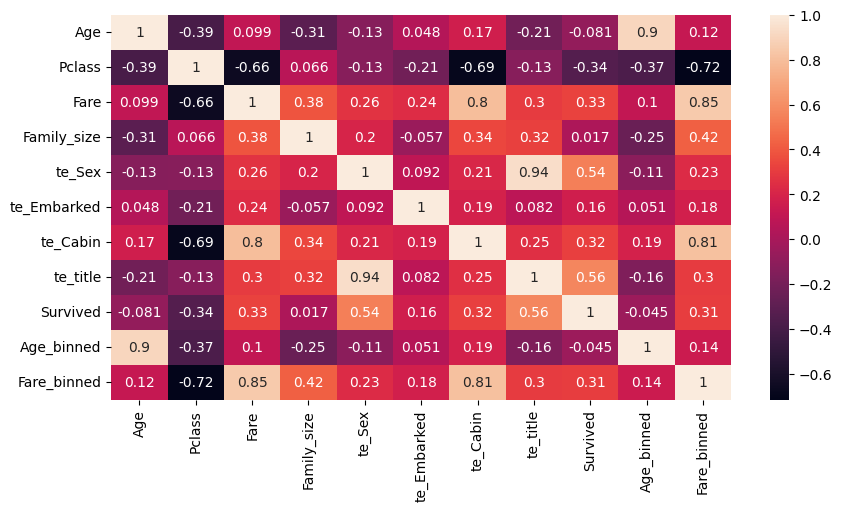

In [1354]:
plt.figure(figsize=(10,5))
sns.heatmap(corr_res,annot=True)
plt.show()

#### CHI-SQUARE TEST FOR CATEGORICAL VARIABLES
We perform Chi-square test for categorical variables to identify association with target. It outputs 2 values - chi-square & p-value. 
P-value is indicative of acceptance of null-hypothesis i.e. there's no association between feature and target. 

- lower p-value (<0.05) implies rejection of null-hypothesis i.e. there exists association. 
- higher p-value (>=0.05) supports independence.

Chi-square measures difference between observed and expected considering null-hypothesis to be true. Hence,

- larger the value of chi-square implying larger difference means greater is the depended between a feature & target.

In [1355]:
y_train = X_train.pop('Survived')

In [1356]:
chi2_stats,p_vals = chi2(X_train,y_train)
chi2_stats = pd.Series(chi2_stats)
p_vals = pd.Series(p_vals)
chi2_stats.index = X_train.columns
p_vals.index = X_train.columns

In [1357]:
p_vals.sort_values()

Fare_binned    3.926466e-14
te_title       4.677294e-14
te_Sex         4.854139e-12
Age            1.064217e-09
Pclass         2.753786e-08
Fare           3.013156e-08
te_Cabin       1.433335e-02
Age_binned     2.046366e-01
Family_size    3.997456e-01
te_Embarked    4.881158e-01
dtype: float64

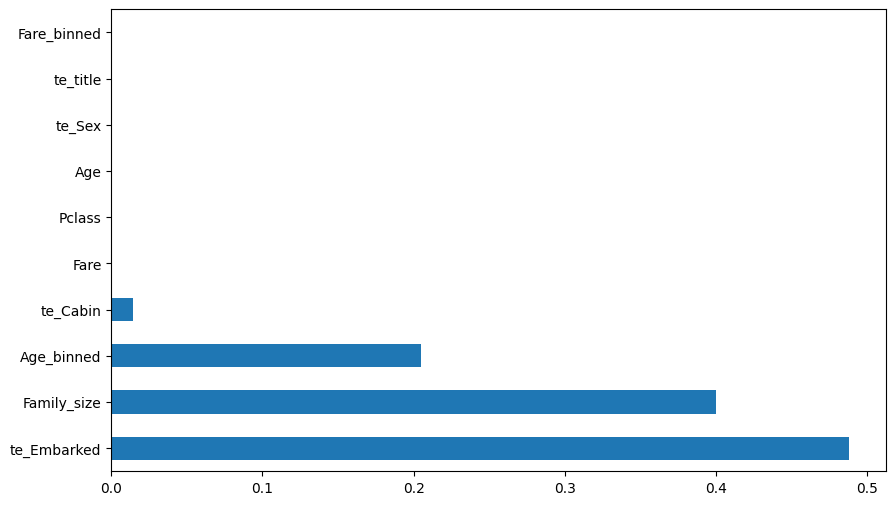

In [1358]:
plt.figure(figsize=(10,6))
p_vals.sort_values(ascending=False).plot(kind='barh',x=p_vals.index,y=p_vals.values)
plt.show()

Observations, 
1. Above plot shows that features "Parch","Sibsp",'titles",'Embarked" & "cabin_sequence" influence the target in decreasing order.

#### PREPROCESSING THROUGH PIPELINING

Here we setup a proper pipeline to have all the above necessary preprocessing on train,valid & test sets prior to feeding the ML models.

In [1359]:
X_train.head()

,Age,Pclass,Fare,Family_size,te_Sex,te_Embarked,te_Cabin,te_title,Age_binned,Fare_binned
0,22.0,3,2.110213,1,0.183807,0.339731,0.236025,0.156098,1,0
1,38.0,1,4.280593,1,0.734694,0.570423,0.580645,0.776596,3,2
2,26.0,3,2.188856,0,0.756098,0.337891,0.232628,0.719424,1,0
3,35.0,1,3.990834,1,0.756098,0.337891,0.582090,0.798077,2,2
4,35.0,3,2.202765,0,0.190065,0.336557,0.248485,0.159524,2,0


In [1360]:
titanic_num_pipeline = make_pipeline(
    StandardScaler()
)

preprocessing = ColumnTransformer([
        ('preprocess_num_cols',titanic_num_pipeline,make_column_selector(dtype_include=np.number))
    ])

#### ML MODELS
We use different ML models like the following,

1. Logistic Regression
2. Random Forest
3. XGBoost 

At first we try the baseline models to see how they perform following which we tune hyperparameters of each & every model to improve performance.

In [1361]:
def oof_auc_check_for_model(X,y,model_pipeline):
    '''
    Function to check for model performance using OOF CV.
    '''
    skf = StratifiedKFold(n_splits=5,random_state=42,shuffle=True)
    oof_score = np.zeros(len(X),dtype=float)
    acc_score = []

    for tr_idx,val_idx in skf.split(X,y):
        tr_fold,y_tr = X.iloc[tr_idx],y[tr_idx]
        val_fold,y_val = X.iloc[val_idx],y[val_idx]

        model = clone(model_pipeline)
        
        model.fit(tr_fold,y_tr)
        oof_score[val_idx] = model.predict_proba(val_fold)[:,1].astype(float)

        y_pred = model.predict(val_fold)
        acc_score.append(accuracy_score(y_val,y_pred))
        
    
    return roc_auc_score(y,oof_score),acc_score

In [1362]:
def Shuffle_training_data(X_tr_preprocessed,target):
    '''
    Function to shuffle final preprocessed training data to prevent ordering biasand to output results that aligns with
    model's performance check with OOF CV.
    '''
    y_tr = X_tr_preprocessed.pop(target)

    # Shuffle X_tr and y together with fixed random_state for reproducibility
    X_tr_preprocessed_shuffled, y_shuffled = shuffle(X_tr_preprocessed, y_tr, random_state=42)

    return X_tr_preprocessed_shuffled,y_shuffled

In [1363]:
X_train = X_train.join(y_train)
X_train_shuffled,y_train_shuffled = Shuffle_training_data(X_train,'Survived')

LOGISTIC REGRESSION BASELINE

In [1365]:
#Logistic Regression baseline
logreg_pipeline = make_pipeline(preprocessing,LogisticRegression(random_state=42,max_iter=1000))

# train & test logistic regression model using k-fold cv
baseline_logreg_result,oof_result = oof_auc_check_for_model(X_train,y_train,logreg_pipeline)
print(f'OOF-CV result is: {baseline_logreg_result}. Foldwise mean & std are: {np.array(oof_result).mean()}, {np.array(oof_result).std()}')

OOF-CV result is: 0.8691746823038167. Foldwise mean & std are: 0.831648986253217, 0.009408215877572831


In [1366]:
# train baseline logreg model on full dataset to fit parameters
logreg_pipeline.fit(X_train_shuffled,y_train_shuffled)

y_pred_prob_logregbase_on_train = logreg_pipeline.predict_proba(X_train_shuffled)[:,1]
print(f"ROC AUC on train set is : {roc_auc_score(y_train_shuffled,y_pred_prob_logregbase_on_train)*100}%")

ROC AUC on train set is : 87.51824156627148%


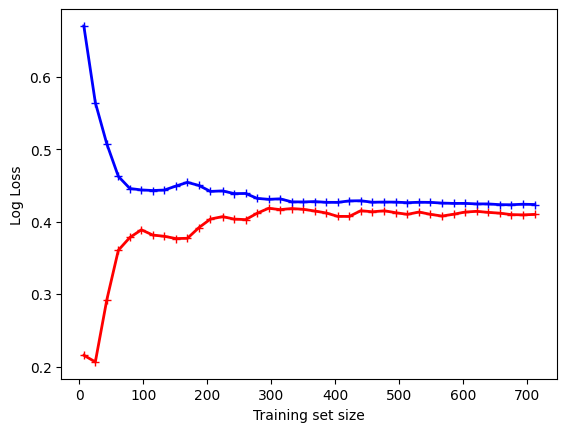

In [1368]:
train_sizes,train_scores,valid_scores = learning_curve(logreg_pipeline,X_train,y_train,train_sizes=np.linspace(0.01,1,40),cv=5,shuffle=True,random_state=42,scoring='neg_log_loss')
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.plot(train_sizes,train_errors,"r-+",linewidth=2,label="train")
plt.plot(train_sizes,valid_errors,"b-+",linewidth=2,label="valid")
plt.xlabel("Training set size")
plt.ylabel("Log Loss")
plt.show()

In [1369]:
# predict on test set
y_pred_test = logreg_pipeline.predict(X_test)

In [1193]:
# save results
# df_beseline_logreg_results = pd.DataFrame(data=list(zip(titanic_test_df['PassengerId'],y_pred_test)),columns=['PassengerId','Survived'])
# df_beseline_logreg_results.to_csv(path_or_buf="./Predictions/Titanic_Survival/Logreg_results/LogReg_besemodel_1_301125.csv",index=False)

RANDOM FOREST BASELINE

In [1371]:
randforest_pipeline = make_pipeline(preprocessing,RandomForestClassifier(random_state=42))

# train & test random forest model using k-fold cv
baseline_randforest_result,oof_result = oof_auc_check_for_model(X_train,y_train,randforest_pipeline)
print(f'OOF-CV ROC_AUC result is: {baseline_logreg_result}. Foldwise mean & std are: {np.array(oof_result).mean()}, {np.array(oof_result).std()}')

OOF-CV ROC_AUC result is: 0.8691746823038167. Foldwise mean & std are: 0.8417362375243236, 0.01267622515798729


In [1372]:
# train baseline logreg model on full dataset to fit parameters
randforest_pipeline.fit(X_train_shuffled,y_train_shuffled)

y_pred_prob_randforestbase_on_train = randforest_pipeline.predict_proba(X_train_shuffled)[:,1]
print(f"ROC AUC on train set is : {roc_auc_score(y_train_shuffled,y_pred_prob_randforestbase_on_train)*100}%")

ROC AUC on train set is : 99.95339745843053%


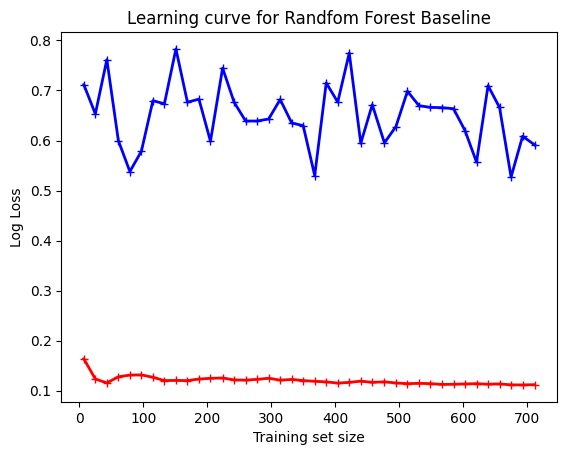

In [1373]:
train_sizes,train_scores,valid_scores = learning_curve(randforest_pipeline,X_train,y_train,train_sizes=np.linspace(0.01,1,40),cv=5,shuffle=True,random_state=42,scoring='neg_log_loss')
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.plot(train_sizes,train_errors,"r-+",linewidth=2,label="train")
plt.plot(train_sizes,valid_errors,"b-+",linewidth=2,label="valid")
plt.xlabel("Training set size")
plt.ylabel("Log Loss")
plt.title("Learning curve for Randfom Forest Baseline")
plt.show()

In [1374]:
# predict on test set
y_pred_randforest_test = randforest_pipeline.predict(X_test)

In [1197]:
# save results
# df_beseline_randforest_results = pd.DataFrame(data=list(zip(titanic_test_df['PassengerId'],y_pred_randforest_test)),columns=['PassengerId','Survived'])
# df_beseline_randforest_results.to_csv(path_or_buf="./Predictions/Titanic_Survival/RandomForest_results/RandForest_basemodel_0_011225.csv",index=False)

XGBOOST BASELINE

In [1375]:
xgb_pipeline = make_pipeline(preprocessing,XGBClassifier(objective='binary:logistic',random_state=42))

xgboost_result,acc_result = oof_auc_check_for_model(X_train,y_train,xgb_pipeline)
print(f'OOF-CV ROC_AUC result is: {xgboost_result}. Foldwise mean & std are: {np.array(acc_result).mean()}, {np.array(acc_result).std()}')

OOF-CV ROC_AUC result is: 0.8543044770395934. Foldwise mean & std are: 0.8091959073504489, 0.02107990719506675


In [1376]:
# train baseline logreg model on full dataset to fit parameters
xgb_pipeline.fit(X_train_shuffled,y_train_shuffled)

y_pred_prob_xgbbase_on_train = xgb_pipeline.predict_proba(X_train_shuffled)[:,1].astype(float)
print(f"ROC AUC on train set is : {roc_auc_score(y_train_shuffled,y_pred_prob_xgbbase_on_train)*100}%")

ROC AUC on train set is : 99.94966925510498%


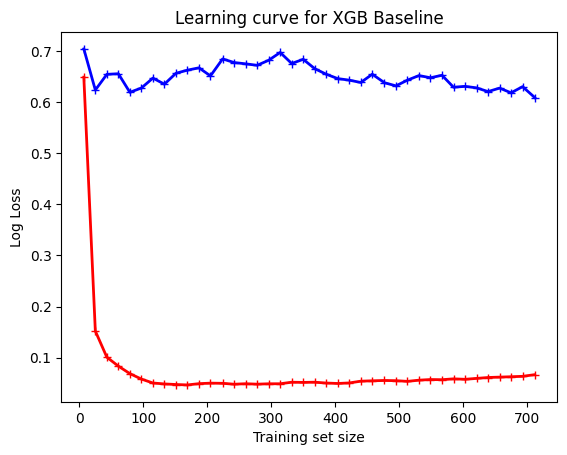

In [1377]:
train_sizes,train_scores,valid_scores = learning_curve(xgb_pipeline,X_train,y_train,train_sizes=np.linspace(0.01,1,40),cv=5,shuffle=True,random_state=42,scoring='neg_log_loss')
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.plot(train_sizes,train_errors,"r-+",linewidth=2,label="train")
plt.plot(train_sizes,valid_errors,"b-+",linewidth=2,label="valid")
plt.xlabel("Training set size")
plt.ylabel("Log Loss")
plt.title("Learning curve for XGB Baseline")
plt.show()

In [1378]:
# predict on test set
y_pred_xgb_test = xgb_pipeline.predict(X_test)

In [722]:
# save results
# df_beseline_xgb_results = pd.DataFrame(data=list(zip(titanic_test_df['PassengerId'],y_pred_xgb_test)),columns=['PassengerId','Survived'])
# df_beseline_xgb_results.to_csv(path_or_buf="./Predictions/Titanic_Survival/XGB_results/xgb_basemodel_0_301125.csv",index=False)

RANDOM FOREST HYPERPARAMETER TUNED

In [1383]:
param_grid_randforest = [
    {
        'randomforestclassifier__max_depth':randint(low=3,high=11),
        'randomforestclassifier__n_estimators':randint(low=200,high=2001),
        'randomforestclassifier__min_samples_leaf':randint(low=3,high=11),
        'randomforestclassifier__max_features':uniform(0.3,1.0),
    }
]

skf = StratifiedKFold(n_splits=3,random_state=42,shuffle=True)
rnd_search = RandomizedSearchCV(randforest_pipeline,param_grid_randforest,n_iter=10,scoring='neg_log_loss',cv=skf)

#fit data to different randomforests formed
rnd_search.fit(X_train_shuffled,y_train_shuffled)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
12 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Library/Frameworks/Python.framework/Versions/3.10/

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"[{'randomforestclassifier__max_depth': <scipy.stats....t 0x3474ddcf0>, 'randomforestclassifier__max_features': <scipy.stats....t 0x347412e30>, 'randomforestclassifier__min_samples_leaf': <scipy.stats....t 0x3474dcc40>, 'randomforestclassifier__n_estimators': <scipy.stats....t 0x3474129b0>}]"
,n_iter,10
,scoring,'neg_log_loss'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [1384]:
# train best xgb model above and run predictions
randforest_best_model = rnd_search.best_estimator_

In [1385]:
rnd_search.best_params_

{'randomforestclassifier__max_depth': 3,
 'randomforestclassifier__max_features': 0.7064863602452129,
 'randomforestclassifier__min_samples_leaf': 8,
 'randomforestclassifier__n_estimators': 737}

In [1388]:
rndforest_result,acc_result = oof_auc_check_for_model(X_train,y_train,randforest_best_model)
print(f'OOF-CV ROC_AUC result is: {rndforest_result}. Foldwise accuracy mean & std are: {np.array(acc_result).mean()}, {np.array(acc_result).std()}')

OOF-CV ROC_AUC result is: 0.8681920344272946. Foldwise accuracy mean & std are: 0.8316427091833531, 0.010761036278919646


In [1389]:
# check performance on train & valid sets
y_pred_prob_randforest_tuned_on_train = randforest_best_model.predict(X_train_shuffled)
print(f"Accuracy on train set is : {accuracy_score(y_train_shuffled,y_pred_prob_randforest_tuned_on_train)*100}%")

Accuracy on train set is : 83.5016835016835%


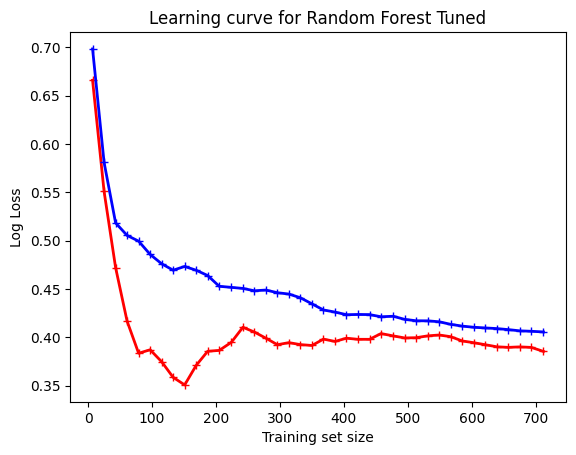

In [1399]:
train_sizes,train_scores,valid_scores = learning_curve(randforest_best_model,X_train,y_train,train_sizes=np.linspace(0.01,1,40),cv=StratifiedKFold(random_state=42,shuffle=True,n_splits=5),scoring='neg_log_loss')
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.plot(train_sizes,train_errors,"r-+",linewidth=2,label="train")
plt.plot(train_sizes,valid_errors,"b-+",linewidth=2,label="valid")
plt.xlabel("Training set size")
plt.ylabel("Log Loss")
plt.title("Learning curve for Random Forest Tuned")
plt.show()

In [1391]:
# run predictions
y_pred_randforest_tuned_model = randforest_best_model.predict(X_test)

In [1392]:
# save results
# df_paramtuned_randforest_results = pd.DataFrame(data=list(zip(titanic_test_df['PassengerId'],y_pred_randforest_tuned_model)),columns=['PassengerId','Survived'])
# df_paramtuned_randforest_results.to_csv(path_or_buf="./Predictions/Titanic_Survival/RandomForest_results/RandForest_tuned_1_011225.csv",index=False)

XGBOOST HYPERPARAMETER TUNED

In [1531]:
xgb_param_grid = [
    {
     'xgbclassifier__max_depth':randint(low=4,high=11),
     'xgbclassifier__colsample_bylevel':uniform(0.5,0.8),
     'xgbclassifier__colsample_bytree':uniform(0.5,0.8),
     'xgbclassifier__n_estimators':randint(low=32,high=91),
     'xgbclassifier__lambda':uniform(1.0,3.0),
     'xgbclassifier__eta':uniform(0.001,0.1)
     }]

skf = StratifiedKFold(n_splits=3,random_state=42,shuffle=True)
xgb_rnd_search = RandomizedSearchCV(xgb_pipeline,xgb_param_grid,n_iter=10,scoring='neg_log_loss',cv=skf,random_state=42)

# fit data to diff randomforest models defined by varying hyperparameters above & carry out cv to evaluate performance
xgb_rnd_search.fit(X_train_shuffled,y_train_shuffled)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
15 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Library/Frameworks/Python.framework/Versions/3.10/

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"[{'xgbclassifier__colsample_bylevel': <scipy.stats....t 0x320feaa40>, 'xgbclassifier__colsample_bytree': <scipy.stats....t 0x30ed7e320>, 'xgbclassifier__eta': <scipy.stats....t 0x343a038b0>, 'xgbclassifier__lambda': <scipy.stats....t 0x342a2d120>, ...}]"
,n_iter,10
,scoring,'neg_log_loss'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [1532]:
# train best xgb model above and run predictions
xgb_best_model_pipeline = xgb_rnd_search.best_estimator_

In [1533]:
xgb_rnd_search.best_params_

{'xgbclassifier__colsample_bylevel': 0.6247956162689621,
 'xgbclassifier__colsample_bytree': 0.5464668897345596,
 'xgbclassifier__eta': 0.08761761457749352,
 'xgbclassifier__lambda': 2.8033450352296265,
 'xgbclassifier__max_depth': 6,
 'xgbclassifier__n_estimators': 53}

In [1534]:
xgboost_result,acc_result = oof_auc_check_for_model(X_train,y_train,xgb_best_model_pipeline)
print(f'OOF-CV ROC_AUC result is: {xgboost_result}. Foldwise mean & std are: {np.array(acc_result).mean()}, {np.array(acc_result).std()}')

OOF-CV ROC_AUC result is: 0.8711692710829898. Foldwise mean & std are: 0.8327474734793798, 0.020087045300324402


In [1535]:
# check performance on train & valid sets
y_pred_prob_xgb_tuned_on_train = xgb_best_model_pipeline.predict(X_train_shuffled)
print(f"Accuracy on train set is : {accuracy_score(y_train_shuffled,y_pred_prob_xgb_tuned_on_train)*100}%")

Accuracy on train set is : 89.78675645342312%


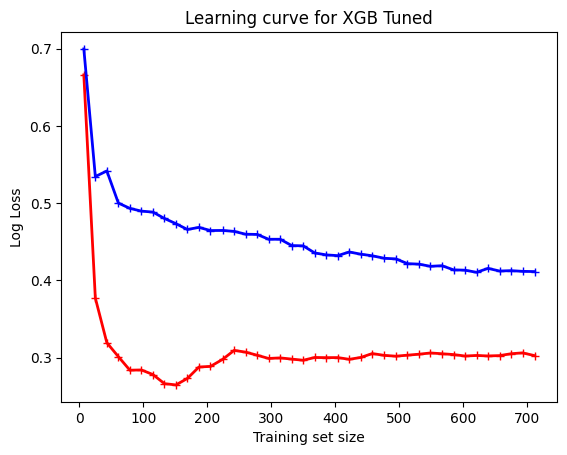

In [1536]:
train_sizes,train_scores,valid_scores = learning_curve(xgb_best_model_pipeline,X_train,y_train,train_sizes=np.linspace(0.01,1,40),cv=StratifiedKFold(random_state=42,shuffle=True,n_splits=5),scoring='neg_log_loss')
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.plot(train_sizes,train_errors,"r-+",linewidth=2,label="train")
plt.plot(train_sizes,valid_errors,"b-+",linewidth=2,label="valid")
plt.xlabel("Training set size")
plt.ylabel("Log Loss")
plt.title("Learning curve for XGB Tuned")
plt.show()

In [1537]:
y_pred_xgb_best_model = xgb_best_model_pipeline.predict(X_test)

In [1458]:
# save results
# df_paramtuned_xgb_results = pd.DataFrame(data=list(zip(titanic_test_df['PassengerId'],y_pred_xgb_best_model)),columns=['PassengerId','Survived'])
# df_paramtuned_xgb_results.to_csv(path_or_buf="./Predictions/Titanic_Survival/XGB_results/xgb_tuned_0_011225.csv",index=False)

#### VOTING CLASSIFIER

In [1564]:
voting_clf = VotingClassifier(estimators=[
    ('rf',randforest_best_model),
    ('xgb',xgb_best_model_pipeline)
])

In [1565]:
voting_clf.voting = 'soft'

In [1566]:
# test performance
votingclf_result,acc_result = oof_auc_check_for_model(X_train,y_train,voting_clf)
print(f'OOF-CV ROC_AUC result is: {votingclf_result}. Foldwise accuracy mean, std are: {np.array(acc_result).mean()}, {np.array(acc_result).std()}')

OOF-CV ROC_AUC result is: 0.872548706313446. Foldwise accuracy mean, std are: 0.8417425145941875, 0.01209633220018171


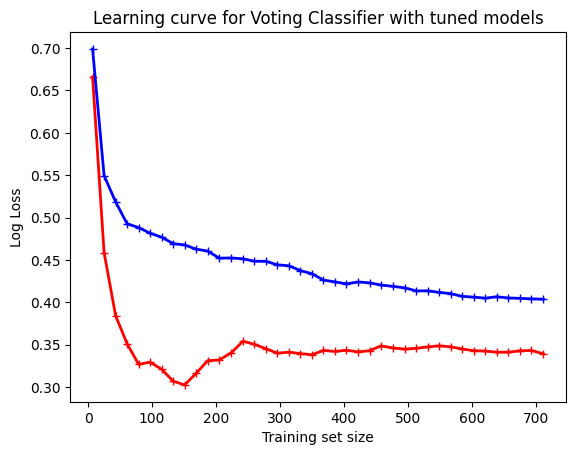

In [1567]:
train_sizes,train_scores,valid_scores = learning_curve(voting_clf,X_train,y_train,train_sizes=np.linspace(0.01,1,40),cv=StratifiedKFold(random_state=42,shuffle=True,n_splits=5),scoring='neg_log_loss')
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.plot(train_sizes,train_errors,"r-+",linewidth=2,label="train")
plt.plot(train_sizes,valid_errors,"b-+",linewidth=2,label="valid")
plt.xlabel("Training set size")
plt.ylabel("Log Loss")
plt.title("Learning curve for Voting Classifier with tuned models")
plt.show()

In [1569]:
# check performance on train & valid sets
voting_clf.fit(X_train_shuffled,y_train_shuffled)

y_pred_prob_votingclf_tuned_on_train = voting_clf.predict(X_train_shuffled)
print(f"Accuracy on train set is : {roc_auc_score(y_train_shuffled,y_pred_prob_votingclf_tuned_on_train)*100}%")

Accuracy on train set is : 84.49813057233247%


In [1562]:
y_pred_votingclf_best_model = voting_clf.predict(X_test)

In [1563]:
# save results
# df_votingclf_results = pd.DataFrame(data=list(zip(titanic_test_df['PassengerId'],y_pred_votingclf_best_model)),columns=['PassengerId','Survived'])
# df_votingclf_results.to_csv(path_or_buf="./Predictions/Titanic_Survival/Votingclf_results/votingclf_0_011225.csv",index=False)